#Project Overview
> This notebook analyzes search console data using DuckDB and Pandas to identify low-performing high-potential content. By scoring and prioritizing refresh candidates using percentile-based opportunity metrics, we output structured recommendations to optimize CTR and overall search performance.

# Content & Refresh Opportunity Scoring Analysis
## 1. Data Loading & Environment Setup
In this step, we install `duckdb`, connect to Hugging Face Hub using secret tokens, and load the search performance dataset into a DuckDB connection for high-performance querying.

In [46]:

!pip install -q duckdb
import duckdb
import pandas as pd
from google.colab import userdata
hf_token = userdata.get("HF_TOKEN")
print("Loading data from Hugging Face...")

con = duckdb.connect()
con.execute(f"""
CREATE SECRET (
    TYPE huggingface,
    TOKEN '{hf_token}'
)
""")

data_path = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet"

query = f"""
SELECT *
FROM read_parquet('{data_path}')
LIMIT 1000
"""
df = con.execute(query).df()

print("Data loaded successfully!")
print("Rows:", len(df))

df.head()




Loading data from Hugging Face...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Data loaded successfully!
Rows: 1000


,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2025-01-27,client_9958f0a7ae1df715,content_3b70a18ea133b2bb,True,True,True,False,30,0,115,...,0,0,0,0,0,0,0,0,0,2025-01
1,2025-01-27,client_9958f0a7ae1df715,content_fe8e8155ce1d47a2,True,True,True,False,5,0,358,...,0,0,0,0,0,0,0,0,0,2025-01
2,2025-01-27,client_9958f0a7ae1df715,content_b4462a1b90640058,True,True,True,False,1,0,34,...,0,0,0,0,0,0,0,0,0,2025-01
3,2025-01-27,client_9958f0a7ae1df715,content_c899aef92518c714,True,True,True,False,6,0,140,...,0,0,0,0,0,0,0,0,0,2025-01
4,2025-01-27,client_9958f0a7ae1df715,content_c7c1d2e68d9d0964,True,True,True,False,5,0,89,...,0,0,0,0,0,0,0,0,0,2025-01


## 2. Exploratory Data Analysis & Quality Checks
Here, we check the overall structure of the dataset including total shape, column names, null value counts, date coverage, and basic summary statistics for key Search Console metrics (impressions, clicks, average position).

In [47]:
print ("numberof rows:",len(df))
print ("Columns")
print(df.columns.tolist())
print("\nFisrt 5 rows:")
df.head()


numberof rows: 1000
Columns
['report_date', 'client_hash_id', 'content_hash_id', 'client_has_gsc', 'client_has_ga4', 'gsc_data_available', 'ga4_data_available', 'gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_sec', 'sessions_organic', 'sessions_direct', 'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai', 'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude', 'ai_meta', 'ai_other', 'scroll_events', 'month']

Fisrt 5 rows:


,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2025-01-27,client_9958f0a7ae1df715,content_3b70a18ea133b2bb,True,True,True,False,30,0,115,...,0,0,0,0,0,0,0,0,0,2025-01
1,2025-01-27,client_9958f0a7ae1df715,content_fe8e8155ce1d47a2,True,True,True,False,5,0,358,...,0,0,0,0,0,0,0,0,0,2025-01
2,2025-01-27,client_9958f0a7ae1df715,content_b4462a1b90640058,True,True,True,False,1,0,34,...,0,0,0,0,0,0,0,0,0,2025-01
3,2025-01-27,client_9958f0a7ae1df715,content_c899aef92518c714,True,True,True,False,6,0,140,...,0,0,0,0,0,0,0,0,0,2025-01
4,2025-01-27,client_9958f0a7ae1df715,content_c7c1d2e68d9d0964,True,True,True,False,5,0,89,...,0,0,0,0,0,0,0,0,0,2025-01


In [48]:
print ("Missing values:")
print (df.isnull().sum())


Missing values:
report_date                 0
client_hash_id              0
content_hash_id             0
client_has_gsc              0
client_has_ga4              0
gsc_data_available          0
ga4_data_available          0
gsc_impressions             0
gsc_clicks                  0
gsc_sum_position            0
gsc_avg_position            0
ga4_pageviews               0
ga4_sessions                0
ga4_users                   0
ga4_engaged_sessions        0
ga4_total_engagement_sec    0
sessions_organic            0
sessions_direct             0
sessions_referral           0
sessions_social             0
sessions_paid               0
sessions_ai                 0
ai_chatgpt                  0
ai_perplexity               0
ai_gemini                   0
ai_copilot                  0
ai_claude                   0
ai_meta                     0
ai_other                    0
scroll_events               0
month                       0
dtype: int64


In [49]:
print ("Data range:")
print(df["report_date"].min())
print(df["report_date"].max())

print ("\nBasic statistics:")
print(df[["gsc_impressions", "gsc_clicks", "gsc_avg_position"]].describe())


Data range:
2025-01-27 00:00:00
2025-01-30 00:00:00

Basic statistics:
       gsc_impressions   gsc_clicks  gsc_avg_position
count      1000.000000  1000.000000       1000.000000
mean          9.896000     0.075000         35.328776
std          20.575095     0.373516         28.890074
min           1.000000     0.000000          0.000000
25%           1.000000     0.000000          9.088235
50%           4.000000     0.000000         27.055556
75%          11.000000     0.000000         58.625000
max         303.000000     6.000000        101.000000


In [50]:
print("Full dataset information:")

query = f"""
SELECT
    COUNT(*) AS total_rows,
    MIN(report_date) AS first_date,
    MAX(report_date) AS last_date
FROM read_parquet('{data_path}')
"""

full_info = con.execute(query).df()
full_info

Full dataset information:


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_rows,first_date,last_date
0,78835655,2025-01-27,2026-06-30


In [51]:
query = f"""
SELECT
    month,
    COUNT(*) AS rows
FROM read_parquet('{data_path}')
GROUP BY month
ORDER BY month
"""
monthly_data = con.execute(query).df()
monthly_data

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,month,rows
0,2025-01,1297
1,2025-02,75985
2,2025-03,167859
3,2025-04,285114
4,2025-05,349923
5,2025-06,329201
6,2025-07,469794
7,2025-08,704962
8,2025-09,845813
9,2025-10,2165471


## 3. Data Aggregation (Monthly, Daily & Content-Level)
We aggregate performance data across multiple granularities:
* **Monthly trend analysis** to understand overall traffic patterns.
* **Daily metric aggregation** within the target timeframe.
* **Content-level aggregation** filtering for items with at least 100 impressions to focus on high-potential opportunities.

In [52]:
query = f"""
SELECT
    report_date,
    COUNT(*) AS rows,
    SUM(gsc_impressions) AS impressions,
    SUM(gsc_clicks) AS clicks
FROM read_parquet('{data_path}')
WHERE report_date >='2026-04-01'
  AND report_date < '2026-07-01'
GROUP BY report_date
ORDER BY report_date
"""
daily_data= con.execute(query).df()
daily_data.head(10)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,report_date,rows,impressions,clicks
0,2026-04-01,331488,10158329.0,26984.0
1,2026-04-02,332184,9610389.0,25504.0
2,2026-04-03,332511,9397252.0,23455.0
3,2026-04-04,332759,9007062.0,22579.0
4,2026-04-05,336120,9136163.0,23252.0
5,2026-04-06,337525,10633895.0,29046.0
6,2026-04-07,337627,11142063.0,30020.0
7,2026-04-08,338242,11002793.0,28729.0
8,2026-04-09,342016,9797406.0,29005.0
9,2026-04-10,343819,8902224.0,24149.0


In [45]:
query = f"""
SELECT
    content_hash_id,
    SUM(gsc_impressions) AS total_impressions,
    SUM(gsc_clicks) AS total_clicks,
    AVG(gsc_avg_position) AS avg_position
FROM read_parquet('{data_path}')
WHERE report_date >= '2026-04-01'
  AND report_date < '2026-07-01'
GROUP BY content_hash_id
HAVING SUM(gsc_impressions) > 100
ORDER BY total_impressions DESC
"""

content_data = con.execute(query).df()

print("Number of content items:", len(content_data))

content_data.head(10)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Number of content items: 151713


,content_hash_id,total_impressions,total_clicks,avg_position
0,content_eadb33b5df496f4a,1986586.0,15428.0,2.279094
1,content_545bb6cc7081ded3,992336.0,4670.0,2.363121
2,content_963de14b1f58978f,908095.0,2405.0,6.146574
3,content_943dc881428182b8,680046.0,914.0,3.498362
4,content_acbcc847f8996314,611708.0,767.0,4.247548
5,content_21309e9a83c83653,596157.0,1025.0,4.982741
6,content_f107e54b10b43725,574397.0,1544.0,4.795604
7,content_0e03de7680314cd5,565913.0,1439.0,2.584560
8,content_33d31496fca9665e,557202.0,125.0,6.175898
9,content_62770e1299963fe4,528618.0,583.0,5.101484


In [53]:
content_data["ctr"] = (
    content_data["total_clicks"] / content_data["total_impressions"]
) * 100

content_data.head(10)

,content_hash_id,total_impressions,total_clicks,avg_position,ctr
0,content_eadb33b5df496f4a,1986586.0,15428.0,2.279094,0.776609
1,content_545bb6cc7081ded3,992336.0,4670.0,2.363121,0.470607
2,content_963de14b1f58978f,908095.0,2405.0,6.146574,0.264840
3,content_943dc881428182b8,680046.0,914.0,3.498362,0.134403
4,content_acbcc847f8996314,611708.0,767.0,4.247548,0.125387
5,content_21309e9a83c83653,596157.0,1025.0,4.982741,0.171935
6,content_f107e54b10b43725,574397.0,1544.0,4.795604,0.268804
7,content_0e03de7680314cd5,565913.0,1439.0,2.584560,0.254279
8,content_33d31496fca9665e,557202.0,125.0,6.175898,0.022434
9,content_62770e1299963fe4,528618.0,583.0,5.101484,0.110288


In [54]:
print("Average CTR:", content_data["ctr"].mean())
print("Average position:", content_data["avg_position"].mean())

Average CTR: 0.31106808157559496
Average position: 20.026368786398155


In [55]:
content_data["refresh_candidate"]=(
    (content_data["total_impressions"] > content_data["total_impressions"].median()) &
    (content_data["ctr"] < content_data["ctr"].median()) &
    (content_data["avg_position"] <= 20)
)
print("Potential refresh candidates:", content_data["refresh_candidate"].sum())

content_data[content_data["refresh_candidate"]].head(10)


Potential refresh candidates: 16714


,content_hash_id,total_impressions,total_clicks,avg_position,ctr,refresh_candidate
3,content_943dc881428182b8,680046.0,914.0,3.498362,0.134403,True
4,content_acbcc847f8996314,611708.0,767.0,4.247548,0.125387,True
8,content_33d31496fca9665e,557202.0,125.0,6.175898,0.022434,True
9,content_62770e1299963fe4,528618.0,583.0,5.101484,0.110288,True
10,content_f352b7cfd0b2f434,523610.0,680.0,4.005842,0.129868,True
12,content_f43118e089ecc69a,508071.0,462.0,6.677966,0.090932,True
13,content_77276ad7a26f4905,504799.0,765.0,5.801716,0.151545,True
23,content_599eba17030c875c,413999.0,431.0,5.853085,0.104107,True
26,content_c1f764a2f362d1c3,396353.0,73.0,7.087442,0.018418,True
31,content_39e19a3ec2d95f9d,382947.0,8.0,18.122212,0.002089,True


## 4. Baseline Metrics & Initial Opportunity Scoring
In this phase, we calculate Click-Through Rate (CTR) and define initial criteria for refresh candidates (high impressions with below-median CTR). An initial linear formula is applied to score content refresh opportunities.

In [56]:
content_data["opportunity_score"] = (
    content_data["total_impressions"] / content_data["total_impressions"].max() * 50
    + (1 - content_data["ctr"] / content_data["ctr"].max()) * 30
    + (1 - content_data["avg_position"] / 20).clip(lower=0) * 20
)
ranked= content_data[content_data["refresh_candidate"]].sort_values(
    "opportunity_score",
    ascending =False

    )
ranked.head(20)


,content_hash_id,total_impressions,total_clicks,avg_position,ctr,refresh_candidate,opportunity_score
3,content_943dc881428182b8,680046.0,914.0,3.498362,0.134403,True,63.542464
4,content_acbcc847f8996314,611708.0,767.0,4.247548,0.125387,True,61.078331
10,content_f352b7cfd0b2f434,523610.0,680.0,4.005842,0.129868,True,59.100211
9,content_62770e1299963fe4,528618.0,583.0,5.101484,0.110288,True,58.141558
8,content_33d31496fca9665e,557202.0,125.0,6.175898,0.022434,True,57.835673
13,content_77276ad7a26f4905,504799.0,765.0,5.801716,0.151545,True,56.818770
12,content_f43118e089ecc69a,508071.0,462.0,6.677966,0.090932,True,56.058751
61,content_d0acf7062bc6b257,312069.0,154.0,2.245414,0.049348,True,55.581409
41,content_6302b8bce0bb84cb,351743.0,525.0,3.732218,0.149257,True,55.037311
23,content_599eba17030c875c,413999.0,431.0,5.853085,0.104107,True,54.508588


In [57]:
print("Score range:")
print(ranked["opportunity_score"].min())
print(ranked["opportunity_score"].max())

print("\nTop 10 opportunities:")
ranked[[
    "content_hash_id",
    "total_impressions",
    "total_clicks",
    "ctr",
    "avg_position",
    "opportunity_score"
]].head(10)

Score range:
29.982794903822935
63.542463636740095

Top 10 opportunities:


,content_hash_id,total_impressions,total_clicks,ctr,avg_position,opportunity_score
3,content_943dc881428182b8,680046.0,914.0,0.134403,3.498362,63.542464
4,content_acbcc847f8996314,611708.0,767.0,0.125387,4.247548,61.078331
10,content_f352b7cfd0b2f434,523610.0,680.0,0.129868,4.005842,59.100211
9,content_62770e1299963fe4,528618.0,583.0,0.110288,5.101484,58.141558
8,content_33d31496fca9665e,557202.0,125.0,0.022434,6.175898,57.835673
13,content_77276ad7a26f4905,504799.0,765.0,0.151545,5.801716,56.818770
12,content_f43118e089ecc69a,508071.0,462.0,0.090932,6.677966,56.058751
61,content_d0acf7062bc6b257,312069.0,154.0,0.049348,2.245414,55.581409
41,content_6302b8bce0bb84cb,351743.0,525.0,0.149257,3.732218,55.037311
23,content_599eba17030c875c,413999.0,431.0,0.104107,5.853085,54.508588


In [58]:
ranked["priority"] = "Low"

ranked.loc[ranked["opportunity_score"] >= 60, "priority"] = "High"
ranked.loc[
    (ranked["opportunity_score"] >= 40) &
    (ranked["opportunity_score"] < 60),
    "priority"
] = "Medium"

print(ranked["priority"].value_counts())
ranked.head(20)

priority
Medium    8357
Low       8355
High         2
Name: count, dtype: int64


,content_hash_id,total_impressions,total_clicks,avg_position,ctr,refresh_candidate,opportunity_score,priority
3,content_943dc881428182b8,680046.0,914.0,3.498362,0.134403,True,63.542464,High
4,content_acbcc847f8996314,611708.0,767.0,4.247548,0.125387,True,61.078331,High
10,content_f352b7cfd0b2f434,523610.0,680.0,4.005842,0.129868,True,59.100211,Medium
9,content_62770e1299963fe4,528618.0,583.0,5.101484,0.110288,True,58.141558,Medium
8,content_33d31496fca9665e,557202.0,125.0,6.175898,0.022434,True,57.835673,Medium
13,content_77276ad7a26f4905,504799.0,765.0,5.801716,0.151545,True,56.818770,Medium
12,content_f43118e089ecc69a,508071.0,462.0,6.677966,0.090932,True,56.058751,Medium
61,content_d0acf7062bc6b257,312069.0,154.0,2.245414,0.049348,True,55.581409,Medium
41,content_6302b8bce0bb84cb,351743.0,525.0,3.732218,0.149257,True,55.037311,Medium
23,content_599eba17030c875c,413999.0,431.0,5.853085,0.104107,True,54.508588,Medium


## 4.1 CTR Validation

In [59]:
print("Average CTR - all content:", content_data["ctr"].mean())
print(
    "Average CTR - refresh candidates:",
    content_data[content_data["refresh_candidate"]]["ctr"].mean()
)

Average CTR - all content: 0.31106808157559496
Average CTR - refresh candidates: 0.08854999606530736


## 4.2 Recommendation Reason Codes

In [60]:
ranked["reason"] = "High impressions + low CTR"

ranked.loc[
    ranked["avg_position"] > 10,
    "reason"
] = "Visible but weaker search position + low CTR"

ranked.loc[
    (ranked["total_impressions"] > ranked["total_impressions"].quantile(0.75)) &
    (ranked["ctr"] < ranked["ctr"].quantile(0.25)),
    "reason"
] = "Very high impressions + very low CTR"

ranked[[
    "content_hash_id",
    "opportunity_score",
    "priority",
    "reason"
]].head(20)

,content_hash_id,opportunity_score,priority,reason
3,content_943dc881428182b8,63.542464,High,High impressions + low CTR
4,content_acbcc847f8996314,61.078331,High,High impressions + low CTR
10,content_f352b7cfd0b2f434,59.100211,Medium,High impressions + low CTR
9,content_62770e1299963fe4,58.141558,Medium,High impressions + low CTR
8,content_33d31496fca9665e,57.835673,Medium,Very high impressions + very low CTR
13,content_77276ad7a26f4905,56.818770,Medium,High impressions + low CTR
12,content_f43118e089ecc69a,56.058751,Medium,High impressions + low CTR
61,content_d0acf7062bc6b257,55.581409,Medium,Very high impressions + very low CTR
41,content_6302b8bce0bb84cb,55.037311,Medium,High impressions + low CTR
23,content_599eba17030c875c,54.508588,Medium,High impressions + low CTR


## 5. Opportunity Score Refinement & Validation
To remove arbitrary linear scaling, we refine the scoring model using percentile ranking (`rank(pct=True)`). We validate the new score by grouping opportunities into score bands and checking CTR correlations to ensure logical consistency.

In [61]:
content_data["impression_score"] = (
    content_data["total_impressions"].rank(pct=True) * 100
)
content_data["ctr_score"] = (
    (1 - content_data["ctr"].rank(pct=True)) * 100
)
content_data["position_score"] = (
    (1 - content_data["avg_position"].rank(pct=True)) * 100
)
content_data["opportunity_score"] = (
    content_data["impression_score"] * 0.4
    + content_data["ctr_score"] * 0.4
    + content_data["position_score"] * 0.2
)
ranked = content_data[
    content_data["refresh_candidate"]
].sort_values(
    "opportunity_score",
    ascending=False
)
ranked.head(10)

,content_hash_id,total_impressions,total_clicks,avg_position,ctr,refresh_candidate,opportunity_score,impression_score,ctr_score,position_score
3310,content_ceea051963ea5e73,39174.0,0.0,5.570016,0.000000,True,91.042561,97.818249,84.062671,91.450963
3258,content_a9762b40c4d07aec,39670.0,0.0,5.726426,0.000000,True,90.892672,97.852524,84.062671,90.632971
6910,content_b04adb0fcfd417f6,22405.0,0.0,5.784835,0.000000,True,89.867711,95.445347,84.062671,90.322517
6030,content_e1c8b55bdfecde2a,24987.0,0.0,7.061046,0.000000,True,88.489450,96.025390,84.062671,82.271130
13300,content_bff860bf1cd9e2b8,13331.0,0.0,6.268735,0.000000,True,87.601458,91.233118,84.062671,87.415713
11923,content_bdd319a905daa89c,14882.0,0.0,6.713942,0.000000,True,87.377482,92.140753,84.062671,84.480565
1135,content_576d3cd50e6243c8,76100.0,12.0,3.176808,0.015769,True,86.725857,99.251877,67.950670,99.224193
83,content_9648c4d1595a0794,272696.0,79.0,3.651217,0.028970,True,86.628305,99.945291,67.337670,98.575600
25375,content_cb1303d6b15d4cc8,6440.0,0.0,3.956462,0.000000,True,86.524688,83.275988,84.062671,97.946122
123,content_7471467133493ce6,229685.0,100.0,2.883665,0.043538,True,86.375723,99.918926,66.259978,99.520806


## 5.1 Score Band Validation


In [62]:
ranked["score_band"] = pd.cut(
    ranked["opportunity_score"],
    bins=[0, 40, 50, 60, 100],
    labels=["Low", "Medium", "High", "Very High"]
)
score_summary = ranked.groupby("score_band", observed=False).agg(
    content_count=("content_hash_id", "count"),
    average_ctr=("ctr", "mean"),
    average_impressions=("total_impressions", "mean")
)
score_summary

,content_count,average_ctr,average_impressions
score_band,,,
Low,0,NaN,NaN
Medium,13,0.166253,1203.153846
High,2495,0.116291,1628.012826
Very High,14206,0.083607,12968.721385


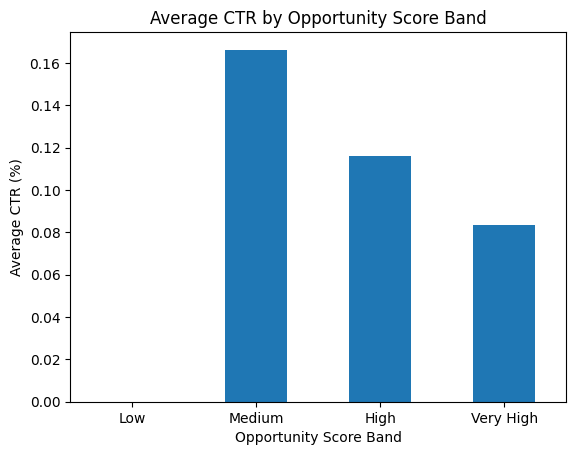

In [63]:
import matplotlib.pyplot as plt
score_summary["average_ctr"].plot(kind="bar")

plt.title("Average CTR by Opportunity Score Band")
plt.xlabel("Opportunity Score Band")
plt.ylabel("Average CTR (%)")
plt.xticks(rotation=0)
plt.show()

## 5.2 Refined Score Validation

In [64]:
print(
    ranked[["opportunity_score", "ctr"]].corr()
)
print("\nTop 10 recommendations:")

ranked[[
    "content_hash_id",
    "total_impressions",
    "total_clicks",
    "ctr",
    "avg_position",
    "opportunity_score"
]].head(10)

                   opportunity_score       ctr
opportunity_score           1.000000 -0.236749
ctr                        -0.236749  1.000000

Top 10 recommendations:


,content_hash_id,total_impressions,total_clicks,ctr,avg_position,opportunity_score
3310,content_ceea051963ea5e73,39174.0,0.0,0.000000,5.570016,91.042561
3258,content_a9762b40c4d07aec,39670.0,0.0,0.000000,5.726426,90.892672
6910,content_b04adb0fcfd417f6,22405.0,0.0,0.000000,5.784835,89.867711
6030,content_e1c8b55bdfecde2a,24987.0,0.0,0.000000,7.061046,88.489450
13300,content_bff860bf1cd9e2b8,13331.0,0.0,0.000000,6.268735,87.601458
11923,content_bdd319a905daa89c,14882.0,0.0,0.000000,6.713942,87.377482
1135,content_576d3cd50e6243c8,76100.0,12.0,0.015769,3.176808,86.725857
83,content_9648c4d1595a0794,272696.0,79.0,0.028970,3.651217,86.628305
25375,content_cb1303d6b15d4cc8,6440.0,0.0,0.000000,3.956462,86.524688
123,content_7471467133493ce6,229685.0,100.0,0.043538,2.883665,86.375723


## 6. Priority Categorization & Final Ranking
We categorize content items into High, Medium, and Low priority tiers based on opportunity score thresholds (High >= 70, Medium >= 50, Low < 50) and generate top recommendations.

In [65]:
ranked["priority"] = "Low"

ranked.loc[
    ranked["opportunity_score"] >= 70,
    "priority"
] = "High"

ranked.loc[
    (ranked["opportunity_score"] >= 50) &
    (ranked["opportunity_score"] < 70),
    "priority"
] = "Medium"

final_recommendations = ranked[[
    "content_hash_id",
    "total_impressions",
    "total_clicks",
    "ctr",
    "avg_position",
    "opportunity_score",
    "priority"
]].head(20)

final_recommendations

,content_hash_id,total_impressions,total_clicks,ctr,avg_position,opportunity_score,priority
3310,content_ceea051963ea5e73,39174.0,0.0,0.000000,5.570016,91.042561,High
3258,content_a9762b40c4d07aec,39670.0,0.0,0.000000,5.726426,90.892672,High
6910,content_b04adb0fcfd417f6,22405.0,0.0,0.000000,5.784835,89.867711,High
6030,content_e1c8b55bdfecde2a,24987.0,0.0,0.000000,7.061046,88.489450,High
13300,content_bff860bf1cd9e2b8,13331.0,0.0,0.000000,6.268735,87.601458,High
11923,content_bdd319a905daa89c,14882.0,0.0,0.000000,6.713942,87.377482,High
1135,content_576d3cd50e6243c8,76100.0,12.0,0.015769,3.176808,86.725857,High
83,content_9648c4d1595a0794,272696.0,79.0,0.028970,3.651217,86.628305,High
25375,content_cb1303d6b15d4cc8,6440.0,0.0,0.000000,3.956462,86.524688,High
123,content_7471467133493ce6,229685.0,100.0,0.043538,2.883665,86.375723,High


##7. Top 10 Opportunities Visualization
We plot a bar chart of the Top 10 content refresh opportunities showing their calculated opportunity scores for visual inspection.

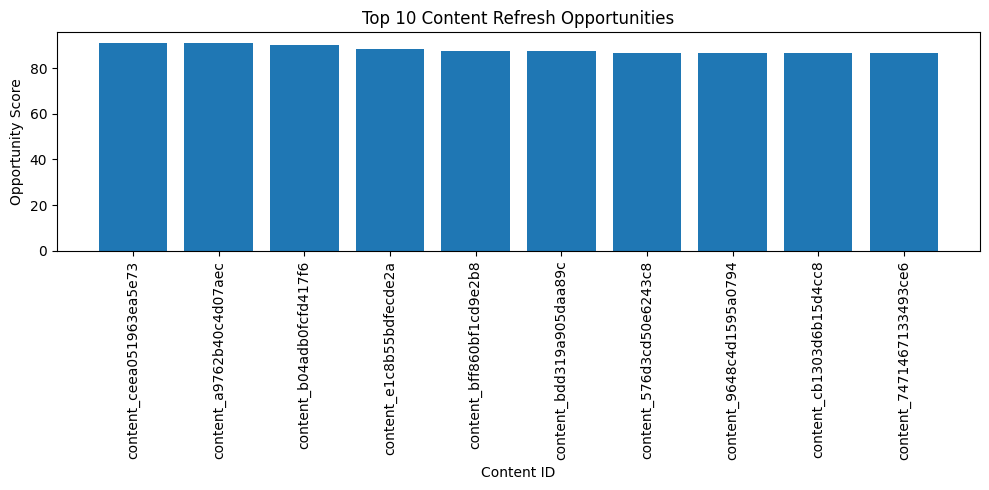

In [66]:
import matplotlib.pyplot as plt

top10 = ranked.head(10).copy()

plt.figure(figsize=(10, 5))
plt.bar(
    top10["content_hash_id"].astype(str),
    top10["opportunity_score"]
)
plt.title("Top 10 Content Refresh Opportunities")
plt.xlabel("Content ID")
plt.ylabel("Opportunity Score")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 8. Exporting Recommendations
We export the top 20 prioritized recommendations into a CSV file (`refresh_opportunity_recommendations.csv`) for operational deployment.

In [67]:
final_recommendations.to_csv(
    "refresh_opportunity_recommendations.csv",
    index=False
)

print("Saved successfully!")
print("Total recommendations:", len(final_recommendations))

Saved successfully!
Total recommendations: 20


## 9. Final Summary & Priority Distribution
In this section, we check overall summary metrics, compute correlation between opportunity score and CTR, and evaluate the final distribution across priority levels (High, Medium, Low).

In [68]:
print("FINAL RESULTS")
print("Total content analyzed:", len(content_data))
print("Refresh candidates:", len(ranked))
print("High priority:", (ranked["priority"] == "High").sum())
print("\nAverage CTR - all content:")
print(round(content_data["ctr"].mean(), 4))
print("\nAverage CTR - refresh candidates:")
print(round(ranked["ctr"].mean(), 4))
print("\nScore vs CTR correlation:")
print(round(ranked["opportunity_score"].corr(ranked["ctr"]), 4))

FINAL RESULTS
Total content analyzed: 151713
Refresh candidates: 16714
High priority: 7010

Average CTR - all content:
0.3111

Average CTR - refresh candidates:
0.0885

Score vs CTR correlation:
-0.2367


## 9.1 Priority Distribution

In [69]:
print("Priority distribution:")
print(ranked["priority"].value_counts())

Priority distribution:
priority
Medium    9691
High      7010
Low         13
Name: count, dtype: int64


###Final Results & Key Findings
This analysis identified content items with strong refresh opportunities based on impressions, click-through rate (CTR), and average search position. A total of 151,713 content items were analyzed, with 16,714 identified as refresh candidates. The final scoring system ranks these candidates by their potential opportunity and assigns priorities for action.
##  Limitations
This analysis identifies patterns and opportunities in the available search data. The results are directional and should be used for decision support rather than as proof of causal impact. A high opportunity score indicates that a content item may deserve review, but it does not guarantee that a refresh will improve performance.

## 10. Priority Distribution Chart
A final bar chart visualising the counts of content items across High, Medium, and Low priority categories.

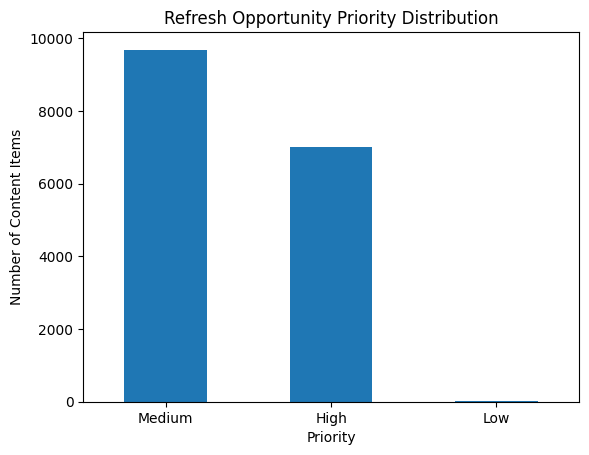

In [70]:
import matplotlib.pyplot as plt

ranked["priority"].value_counts().plot(kind="bar")

plt.title("Refresh Opportunity Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Number of Content Items")
plt.xticks(rotation=0)
plt.show()

# Capstone Research Paper

## Title

Refresh / Content Opportunity Scoring: A Data-Driven Approach to Prioritizing Content for Review
This project studies how search performance data can be used to identify content that may be worth reviewing or refreshing. Using real FlyRank search data, we analyzed impressions, clicks, click-through rate (CTR), and average search position for 151,713 content items. We identified 16,714 content items as potential refresh candidates and created an opportunity score using impressions, CTR, and search position. The final ranking helps prioritize content for review based on observed search-performance signals. The results are intended as decision-support recommendations, not as proof that refreshing a page will cause better performance.
## Introduction / Problem Statement

The main goal of this project is to identify which content items may deserve a refresh or closer review. Instead of reviewing a large number of content items manually, the analysis uses search-performance signals to rank potential opportunities. The resulting ranking can help content teams focus their attention on items with stronger observed opportunities.
## Data

The analysis used the FlyRank ML Internship dataset. The available data covered 2025-01-27 to 2026-06-30 and contained 78,835,655 rows. After aggregation, 151,713 unique content items were analyzed. The analysis focused on impressions, clicks, CTR, and average search position. Client names, domains, URLs, private queries, credentials, and raw exports were not used in the public-facing analysis.
## Methodology

The analysis first aggregated search data at the content level and calculated total impressions, total clicks, CTR, and average search position. Refresh candidates were then identified using the project's search-performance criteria. An opportunity score was created from three signals: impression volume, CTR, and average position. The refined score gives higher opportunity to content with stronger visibility and weaker click performance. Candidates were then ranked and assigned priority levels to create an actionable refresh list.
## Results

The analysis covered 151,713 content items and identified 16,714 potential refresh candidates. The average CTR across all analyzed content was 0.3111, while the average CTR among refresh candidates was 0.0885. The refined opportunity score showed a negative correlation of -0.2367 with CTR, indicating that higher-scored opportunities generally had lower CTR. The final ranking produced a prioritized list of content items for review, with 7,010 classified as High priority, 9,691 as Medium priority, and 13 as Low priority.
## Limitations & Honest Framing

This analysis identifies patterns in observed search-performance data and should be treated as decision support. A high opportunity score does not prove that refreshing a page will cause higher CTR or better rankings. The analysis does not establish causal impact, and the recommendations should therefore be treated as review priorities rather than guaranteed outcomes.
## Ranked Recommendations

The final scoring system produces a ranked list of content items for review. The highest-ranked items should be reviewed first because they combine stronger opportunity signals across impressions, CTR, and average search position. The exported top-20 recommendation list provides a practical starting point for a content refresh workflow.
## Reproducibility

The workflow can be reproduced from the accompanying notebook. It covers data loading, quality checks, content-level aggregation, CTR calculation, refresh-candidate identification, opportunity scoring, validation, priority assignment, and recommendation export.
## Acknowledgments & Data Credit

Built on the FlyRank ML Internship dataset.

Data source: FlyRank AI — https://flyrank.ai

